# Knockdown, CRISPRa and overexpression in the 256-gene GRNs

This notebook extends the workflow in `small_GRN-V1.ipynb` and `small_GRN-V3-Copy1.ipynb`.
It keeps the same **double logFC − single-A logFC − single-B logFC** residual,
percentiles and histograms. It adds dose sweeps, excludes both manipulated genes,
and distinguishes the fraction of affected readouts from the fraction of gene pairs
with at least one interaction. All included outputs were executed.

**Scope:** V1 seed 42 and V3 seed 5, 256 genes, all 256 singles and the same 4,096 uniformly
sampled unordered pairs (of 32,640) in each of 19 conditions. The sampling seed is 20260928.
These are deterministic equilibria of the original model (`s=0`), rather than the original
noisy time averages. Failed equilibria are retained with flags and excluded from equilibrium
statistics. This is a model pilot, not a measurement of biological CRISPR interaction rates.

Start here; `small_GRN-modalities-robustness.ipynb` checks thresholds, expression floors,
the common converged subset, target inclusion, actuator assumptions, and additional seeds.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from threadpoolctl import threadpool_limits

ROOT = Path.cwd()
assert (ROOT / 'src' / 'grn.py').exists(), 'Open this notebook from the repository root.'
sys.path.insert(0, str(ROOT / 'src'))
from grn import grn
from modality_analysis import (
    CONDITIONS, make_network, choose_pairs, screen, load_screen, residuals,
    summarize, shared_downstream, load_network, save_network, run_conditions
)
threadpool_limits(limits=1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
N_GENES = 256
RESULTS = ROOT / 'results' / f'modalities_{N_GENES}'
FIGURES = RESULTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
SEEDS = {'V1': 42, 'V3': 5}
CORE = ['KO', 'KD_90pct', 'KD_50pct', 'CRISPRa_2x', 'CRISPRa_10x', 'OE_10x', 'OE_30x']
def get_data(version, condition):
    return load_screen(RESULTS / f'{version}_seed{SEEDS[version]}' / condition / f'{condition}.npz')
def get_network(version):
    return load_network(RESULTS / f'{version}_seed{SEEDS[version]}' / 'network.npz')

## Perturbation sizes and their meaning

Published efficiencies vary by gene, guide, construct and cell type. Gilbert et al. reported
90–99% knockdown for their optimized CRISPRi system. In a selected 12-gene panel,
Konermann et al. found SAM activation above 15× for eight genes, while activation depended
strongly on basal expression. Thus neither “CRISPRa means 2×” nor “ORF expression means 30×”
is a universal calibration. Here 2–30× values are **sensitivity scenarios**, not claimed averages.

| Intervention | Model implementation | Dose grid |
|---|---|---|
| KO reference | Hold target RNA at zero; downstream-equivalent to removing outgoing edges | 0× |
| KD / CRISPRi | Multiply endogenous synthesis capacity | 1%, 10%, 50%, 75% remaining |
| CRISPRa, capacity model | Multiply endogenous synthesis capacity | 1.25×, 2×, 5×, 10× |
| Overexpression, transgene model | Add constant synthesis outside the sigmoid | 2×, 10×, 30× nominal total expression |
| Dose-matched control | Hold target RNA at a fixed multiple of WT | 0.1×, 0.5×, 2×, 10×, 30× |
| Alternative CRISPRa model | Shift the sigmoid input, retaining its original ceiling | 2×, 10× nominal; cap explicitly recorded |

For production and transgene interventions, network feedback can change the achieved target fold.
Increasing production capacity changes the ceiling; shifting the promoter input retains it.
The model cannot tell us which abstraction best describes a particular experimental CRISPRa system.
The alternative implementations make that assumption visible.

References: [Aguirre et al., PLOS 2025](https://doi.org/10.1371/journal.pcbi.1013387),
[Gilbert et al., Cell 2014](https://doi.org/10.1016/j.cell.2014.09.029),
[Konermann et al., Nature 2015](https://doi.org/10.1038/nature14136).

## Run or load the pilot

In [2]:
# Existing results load immediately. Opt in to recomputation below.
RUN_SCREEN = False
PAIR_COUNT = 4096  # None = all n*(n-1)/2 unordered pairs
if RUN_SCREEN:
    output = ROOT / 'results' / f'modalities_{N_GENES}'
    for version, seed in SEEDS.items():
        graph = make_network(version, seed=seed, n=N_GENES)
        pairs = choose_pairs(N_GENES, PAIR_COUNT)
        folder = output / f'{version}_seed{seed}'
        save_network(graph, folder / 'network.npz')
        # Matches the runner's per-condition checkpoint layout.
        for condition in CONDITIONS:
            run_conditions(graph, pairs, folder / condition[0], conditions=[condition])
# Faster command-line equivalent (processes, one BLAS thread each):
# python job_script/run_modalities.py --pairs 4096 --workers 4

# Build this table from the per-screen summaries, which also supports resumed runs.
summary = pd.concat([pd.read_csv(p) for p in RESULTS.glob('*_seed*/*/summary.csv')], ignore_index=True)
summary = summary.sort_values(['network', 'condition']).reset_index(drop=True)
assert len(summary) == 2 * len(CONDITIONS)
summary.to_csv(RESULTS / 'summary.csv', index=False)
print(f'{len(summary)} screens; {summary.n_pairs.sum():,} double-condition simulations; '
      f'{256*len(summary):,} single-condition simulations')

38 screens; 155,648 double-condition simulations; 9,728 single-condition simulations


## Reuse the existing `grn` object

In [3]:
G = get_network('V1')
examples = {
    '90% knockdown': G.knockdown_nodes([0, 1], remaining=.1, stats=('convergence', 'diagnostics')),
    '2x CRISPRa': G.crispra_nodes([0, 1], fold_change=2, stats=('convergence', 'diagnostics')),
    '30x OE': G.overexpress_nodes([0, 1], fold_change=30, stats=('convergence', 'diagnostics')),
}
display(pd.DataFrame({name: {'converged': out['convergence'],
                            'achieved target folds': out['diagnostics']['achieved_fold']}
                      for name, out in examples.items()}).T)
# Exact-dose alternative: G.crispra_nodes([0, 1], 2, mechanism='clamp')
# Original noisy simulation: G.crispri_nodes([0, 1], remaining=.1,
#     solver='trajectory', s=1e-4, dt=.01, tmax=20000, burnin=5000)

,converged,achieved target folds
90% knockdown,True,"[0.1200122738139761, 0.1027211675641783]"
2x CRISPRa,True,"[1.487797784546413, 1.9220441099701617]"
30x OE,True,"[29.0000036945954, 33.75647190961984]"


## What counts as nonadditive?

For gene $g$ and pair $(a,b)$, use

$$I_{ab,g}=\log_2(x_{ab,g}/x_{WT,g})-\log_2(x_{a,g}/x_{WT,g})-\log_2(x_{b,g}/x_{WT,g}).$$

Zero is additive in log fold changes, equivalently multiplicative in expression. This differs
from the expression-scale baseline $x_a+x_b-x_{WT}$ used in some prediction benchmarks.

The primary descriptive threshold is $|I|>0.1$ log2 units (about 7.2% discrepancy from the
multiplicative prediction); the full analysis also reports 0.01, 0.5 and 1. These are effect-size
cutoffs, not statistical significance tests. A pair can qualify because of one readout.

Both targeted genes are removed **from every comparison**. The primary readout mask also
requires expression ≥ $10^{-4}$ in WT, both singles and the double, avoiding huge ratios involving
nearly silent genes. This is an analyst-chosen model-unit floor motivated by the original
noise amplitude, not an experimental detection limit. Alternative floors are in notebook 2.

In [4]:
table = summary[summary.condition.isin(CORE)].copy()
table['valid pairs (%)'] = 100 * table.n_valid_pairs / table.n_pairs
table['readouts nonadditive (%)'] = 100 * table['readout_gt_0.1']
table['pairs with any interaction (%)'] = 100 * table['pair_any_gt_0.1']
display(table[['network', 'condition', 'n_valid_pairs', 'n_readouts', 'valid pairs (%)',
               'readouts nonadditive (%)', 'pairs with any interaction (%)']].round(3))

,network,condition,n_valid_pairs,n_readouts,valid pairs (%),readouts nonadditive (%),pairs with any interaction (%)
0,V1,CRISPRa_10x,4096,1037051,100.000,0.727,8.618
2,V1,CRISPRa_2x,4096,1040138,100.000,0.070,1.416
5,V1,KD_50pct,4096,1040384,100.000,0.018,0.464
6,V1,KD_90pct,4096,1040384,100.000,0.109,1.538
8,V1,KO,4096,1040384,100.000,0.141,2.002
9,V1,OE_10x,4096,1037278,100.000,0.591,5.737
11,V1,OE_30x,4096,1032405,100.000,1.077,8.325
19,V3,CRISPRa_10x,2515,485050,61.401,14.842,39.165
21,V3,CRISPRa_2x,2785,572873,67.993,4.512,19.031
24,V3,KD_50pct,3052,631376,74.512,3.334,15.072


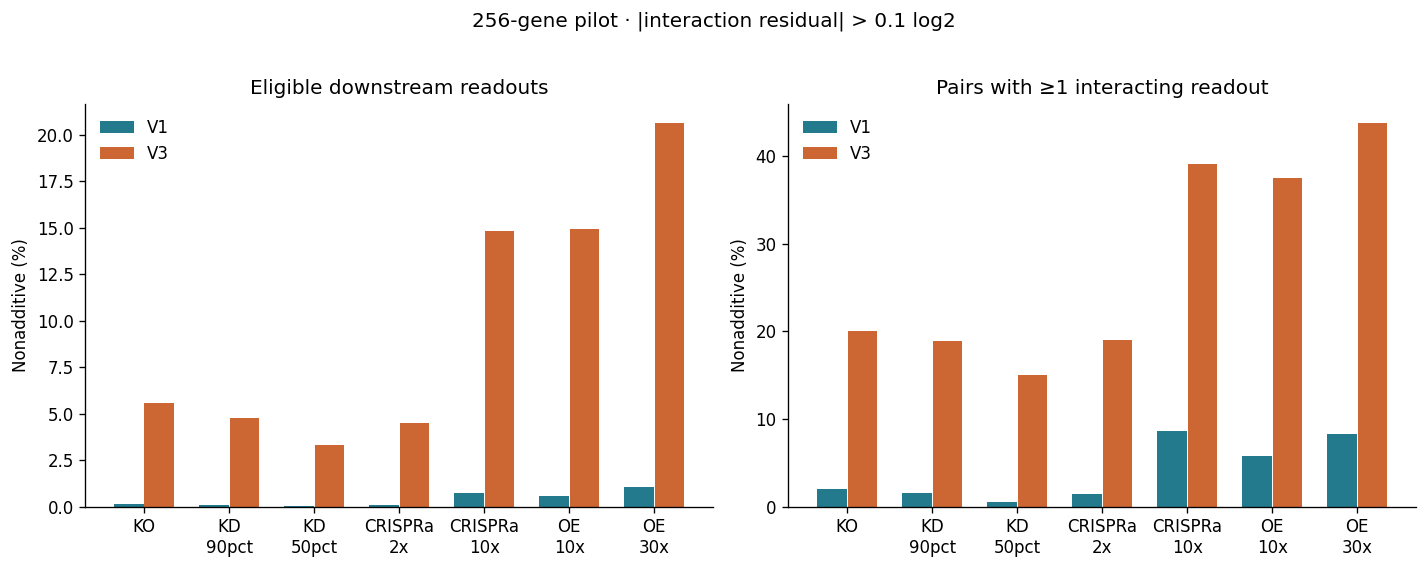

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
x = np.arange(len(CORE))
for version, offset, color in [('V1', -.18, '#237a8c'), ('V3', .18, '#cc6633')]:
    t = summary[summary.network.eq(version)].set_index('condition').loc[CORE]
    for ax, column in zip(axes, ['readout_gt_0.1', 'pair_any_gt_0.1']):
        ax.bar(x + offset, 100*t[column], width=.35, color=color, label=version)
for ax, title in zip(axes, ['Eligible downstream readouts', 'Pairs with ≥1 interacting readout']):
    ax.set_xticks(x, [s.replace('_', '\n') for s in CORE], rotation=0)
    ax.set_ylabel('Nonadditive (%)')
    ax.set_title(title)
    ax.legend(frameon=False)
fig.suptitle('256-gene pilot · |interaction residual| > 0.1 log2', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / 'modality_comparison.png', bbox_inches='tight')
plt.show()

V3 percentages are conditional on convergence and expression eligibility. Changing those
denominators can change the comparison. Notebook 2 repeats it on the intersection of valid
pairs and readouts across modalities, and shows the number of unresolved cases separately.

## The original residual calculation, explicitly

In [6]:
VERSION, CONDITION = 'V1', 'KO'  # Edit these two values to inspect another screen.
data = get_data(VERSION, CONDITION)
wt_expression = data['wt']
pairs = data['pairs']
with np.errstate(divide='ignore', invalid='ignore'):
    single_logfc = np.log2(data['single']) - np.log2(wt_expression)
    double_logfc = np.log2(data['double']) - np.log2(wt_expression)
    expected_additive = single_logfc[pairs[:, 0]] + single_logfc[pairs[:, 1]]
    interaction_residuals = double_logfc - expected_additive
analysis = residuals(data, expression_floor=1e-4, exclude_targets=True)
errors = interaction_residuals[analysis['mask']]
assert np.allclose(errors, analysis['log'][analysis['mask']])
quantiles = [0, .001, .01, .05, .5, .95, .99, .999, 1]
display(pd.DataFrame({'quantile': quantiles, 'interaction residual': np.quantile(errors, quantiles)}))
print('Eligible readouts:', len(errors), 'Mean:', errors.mean(), 'SD:', errors.std())

Eligible readouts: 1040384 Mean: -5.577458991765397e-06 SD: 0.015237093514789565


,quantile,interaction residual
0,0.000,-2.551206e+00
1,0.001,-6.953733e-02
2,0.010,-1.159070e-03
3,0.050,-2.019386e-09
4,0.500,0.000000e+00
5,0.950,3.405438e-09
6,0.990,1.111197e-03
7,0.999,6.853790e-02
8,1.000,2.458894e+00


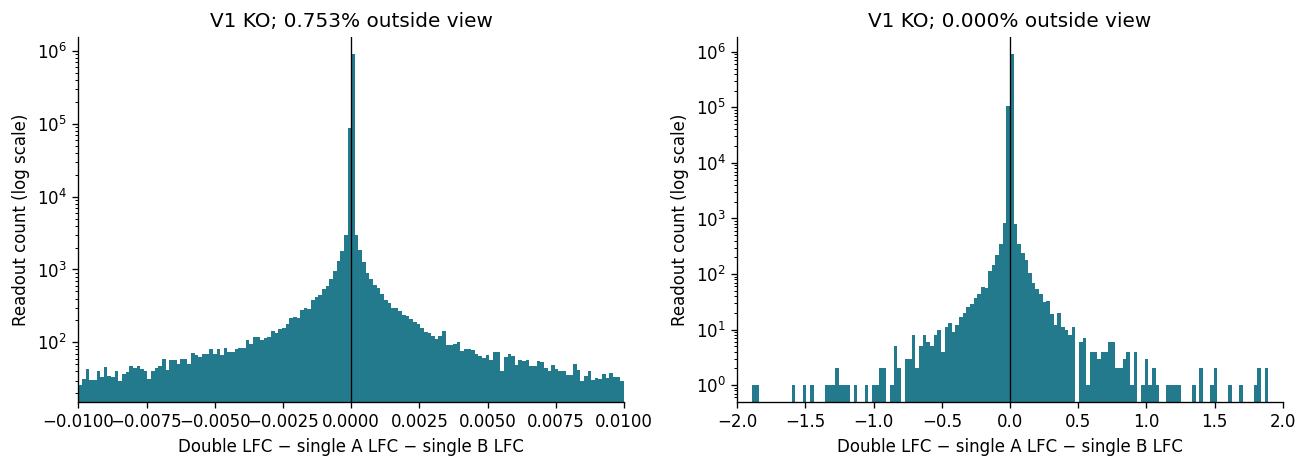

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, limits in zip(axes, [(-.01, .01), (-2, 2)]):
    ax.hist(errors, bins=np.linspace(*limits, 151), color='#237a8c', log=True)
    ax.axvline(0, color='black', lw=.8)
    ax.set_xlim(limits)
    ax.set_xlabel('Double LFC − single A LFC − single B LFC')
    ax.set_ylabel('Readout count (log scale)')
    outside = np.mean((errors < limits[0]) | (errors > limits[1]))
    ax.set_title(f'{VERSION} {CONDITION}; {100*outside:.3f}% outside view')
fig.tight_layout()
fig.savefig(FIGURES / 'example_histograms.png', bbox_inches='tight')
plt.show()

## Percentiles and the whole tail

,network,condition,abs_residual_p50,abs_residual_p95,abs_residual_p99,abs_residual_p99.9,log_additive_rmse
0,V1,CRISPRa_10x,0.000000,0.000456,0.063839,0.657997,0.057807
2,V1,CRISPRa_2x,0.000000,0.000019,0.004055,0.075010,0.008841
5,V1,KD_50pct,0.000000,0.000007,0.001418,0.030762,0.003784
6,V1,KD_90pct,0.000000,0.000023,0.004810,0.108176,0.012314
8,V1,KO,0.000000,0.000028,0.005942,0.134391,0.015237
9,V1,OE_10x,0.000000,0.000328,0.049484,0.490147,0.041329
11,V1,OE_30x,0.000000,0.000967,0.110373,0.920641,0.073083
19,V3,CRISPRa_10x,0.000012,1.858934,6.546347,11.702116,1.200738
21,V3,CRISPRa_2x,0.000001,0.081153,1.208368,6.276134,0.400003
24,V3,KD_50pct,0.000000,0.045532,0.669239,5.253198,0.316137


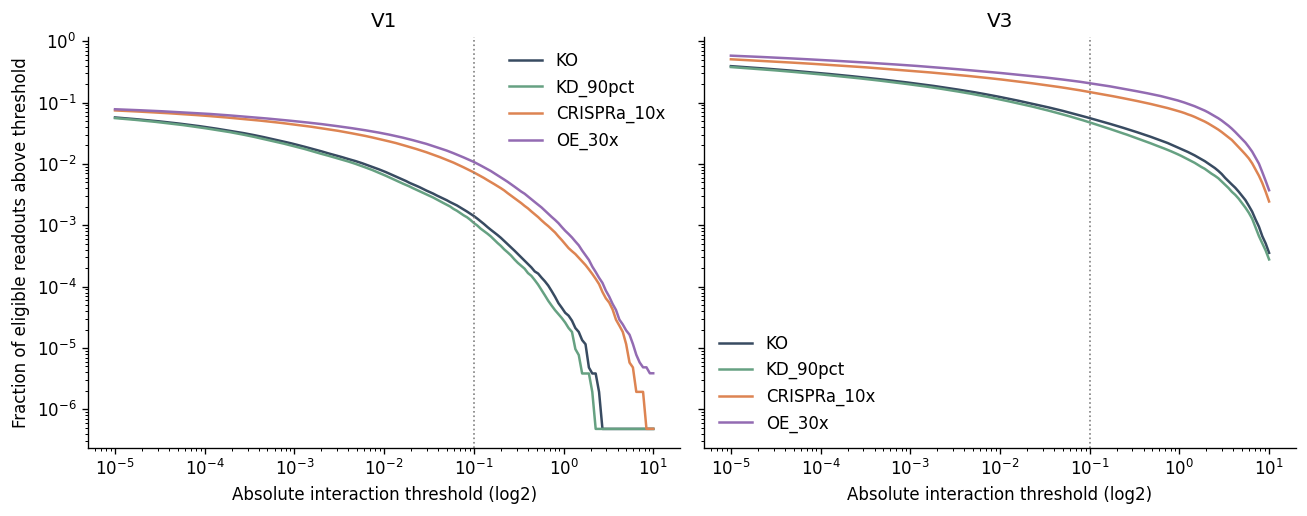

In [8]:
display(summary[summary.condition.isin(CORE)][[
    'network', 'condition', 'abs_residual_p50', 'abs_residual_p95',
    'abs_residual_p99', 'abs_residual_p99.9', 'log_additive_rmse']].round(6))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
thresholds = np.logspace(-5, 1, 160)
colors = ['#384b61', '#66a182', '#dd8452', '#936bb2']
for ax, version in zip(axes, ['V1', 'V3']):
    for name, color in zip(['KO', 'KD_90pct', 'CRISPRa_10x', 'OE_30x'], colors):
        r = residuals(get_data(version, name))
        values = np.sort(np.abs(r['log'][r['mask']]))
        fraction = (len(values) - np.searchsorted(values, thresholds, side='right')) / len(values)
        ax.plot(thresholds, np.maximum(fraction, .5/len(values)), label=name, color=color)
    ax.set(xscale='log', yscale='log', xlabel='Absolute interaction threshold (log2)', title=version)
    ax.axvline(.1, color='grey', ls=':', lw=1)
    ax.legend(frameon=False)
axes[0].set_ylabel('Fraction of eligible readouts above threshold')
fig.tight_layout()
fig.savefig(FIGURES / 'residual_tails.png', bbox_inches='tight')
plt.show()

## Achieved doses and convergence

In [9]:
display(summary[['network', 'condition', 'dose', 'achieved_fold_p10',
                 'achieved_fold_p50', 'achieved_fold_p90', 'n_single_converged',
                 'n_double_converged', 'n_valid_pairs', 'target_cap_fraction']].round(4))

,network,condition,dose,achieved_fold_p10,achieved_fold_p50,achieved_fold_p90,n_single_converged,n_double_converged,n_valid_pairs,target_cap_fraction
0,V1,CRISPRa_10x,10.00,9.9955,10.0000,10.0867,256,4096,4096,0.0000
1,V1,CRISPRa_1p25x,1.25,1.2500,1.2500,1.2506,256,4096,4096,0.0000
2,V1,CRISPRa_2x,2.00,1.9999,2.0000,2.0034,256,4096,4096,0.0000
3,V1,CRISPRa_5x,5.00,4.9986,5.0000,5.0325,256,4096,4096,0.0000
4,V1,KD_25pct,0.75,0.7496,0.7500,0.7500,256,4096,4096,0.0000
5,V1,KD_50pct,0.50,0.4995,0.5000,0.5000,256,4096,4096,0.0000
6,V1,KD_90pct,0.10,0.0998,0.1000,0.1000,256,4096,4096,0.0000
7,V1,KD_99pct,0.01,0.0100,0.0100,0.0100,256,4096,4096,0.0000
8,V1,KO,0.00,0.0000,0.0000,0.0000,256,4096,4096,0.0000
9,V1,OE_10x,10.00,9.9996,10.0000,10.0087,256,4096,4096,0.0000


## Continue with a larger network

The original notebooks and KO method remain usable. New public methods are in `src/grn.py`;
the small `src/modality_analysis.py` module only handles batching, masks and saved results.
Every NPZ contains expression arrays, pair identities, convergence flags, solver settings,
package versions and a graph fingerprint. Numerical network snapshots avoid relying on
future random-generator or NetworkX behavior.

For a 2,000-gene pilot, use a new results directory and keep a sampled pair set first:

```python
G = make_network('V1', seed=42, n=2000)
pairs = choose_pairs(G.n, count=4096)
run_conditions(G, pairs, 'results/my_2000_gene_pilot',
               conditions=[('KD90', 'production', .1), ('A10', 'production', 10.)],
               batch_size=64)
```

There are 1,999,000 unordered pairs at 2,000 genes; storing their expression matrix alone
requires about 32 GB at float64. The solver avoids storing trajectories, but a full screen
still returns one expression matrix, so shard pairs into separate calls for an exhaustive run.
No 2,000-gene experiment was run for this deliverable. No new MLP was trained; these analyses
quantify signal available beyond the additive oracle, which does not guarantee a learned model
can recover it under a particular training split.